In [4]:
from all_imports import *
import re

In [5]:
# 1. Create a working copy of the reviews dataset
reviews_text = orderReviews_df.copy()

# 2. Flag if a comment was left, and calculate its length (handling NaN values)
reviews_text['has_comment'] = reviews_text['review_comment_message'].notna()
reviews_text['comment_length'] = reviews_text['review_comment_message'].astype(str).apply(lambda x: len(x) if x != 'nan' else 0)

# 3. Filter down to only reviews that actually have text for the keyword analysis
text_only = reviews_text[reviews_text['has_comment']].copy()

# 4. Basic Keyword Extraction Function (Portuguese)
def get_top_keywords(text_series, top_n=10):
    # Combine all text, convert to lowercase
    text = " ".join(text_series.astype(str).tolist()).lower()
    # Remove basic punctuation
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    
    # Basic Portuguese stopwords to ignore common words (the, and, of, etc.)
    stopwords = {'e', 'o', 'a', 'do', 'da', 'de', 'que', 'com', 'um', 'uma', 'na', 'no', 'para', 
                 'produto', 'foi', 'não', 'nao', 'mas', 'eu', 'me', 'por', 'como', 'muito', 'bem'}
    
    meaningful_words = [word for word in words if word not in stopwords and len(word) > 2]
    return pd.Series(meaningful_words).value_counts().head(top_n)

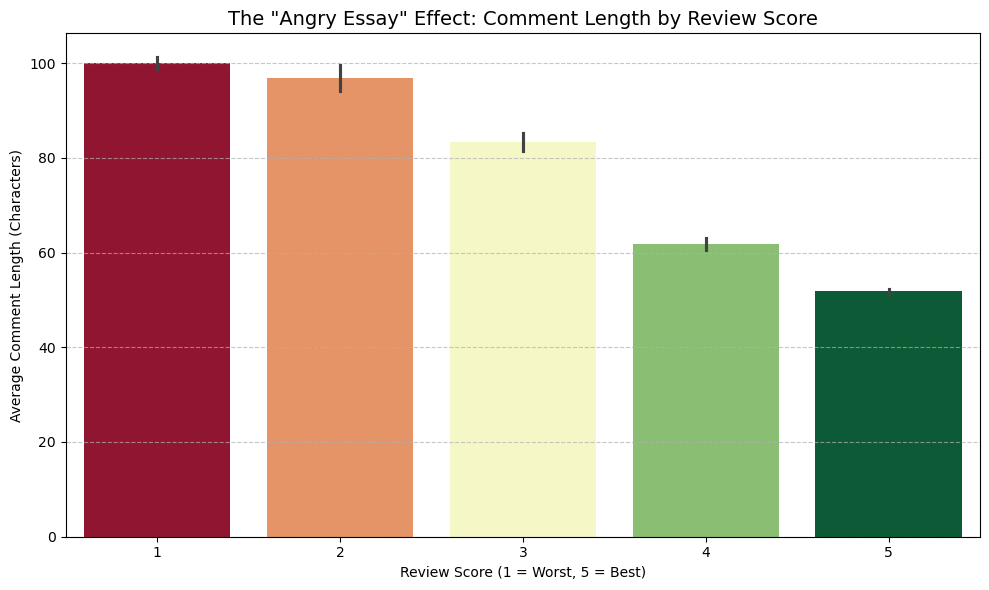

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=text_only, 
    x='review_score', 
    y='comment_length', 
    palette='RdYlGn',
    hue='review_score',
    legend=False
)

plt.title('The "Angry Essay" Effect: Comment Length by Review Score', fontsize=14)
plt.xlabel('Review Score (1 = Worst, 5 = Best)')
plt.ylabel('Average Comment Length (Characters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

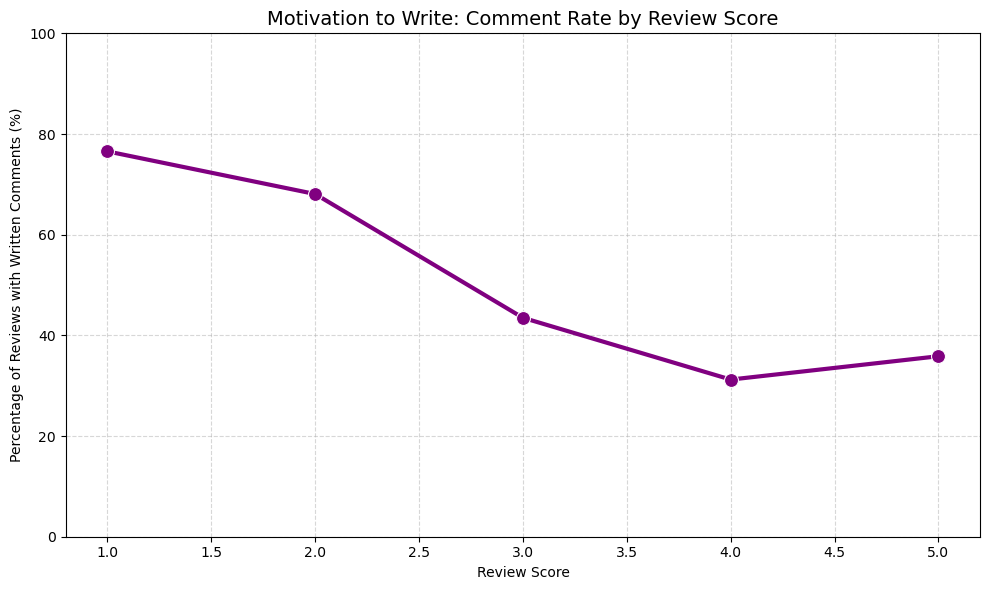

In [10]:
# Calculate the percentage of users who left a comment for each score
comment_rates = reviews_text.groupby('review_score')['has_comment'].mean() * 100
comment_rates = comment_rates.reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=comment_rates, 
    x='review_score', 
    y='has_comment', 
    marker='o', 
    color='purple', 
    linewidth=3, 
    markersize=10, 
    legend=False    
)

plt.title('Motivation to Write: Comment Rate by Review Score', fontsize=14)
plt.xlabel('Review Score')
plt.ylabel('Percentage of Reviews with Written Comments (%)')
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

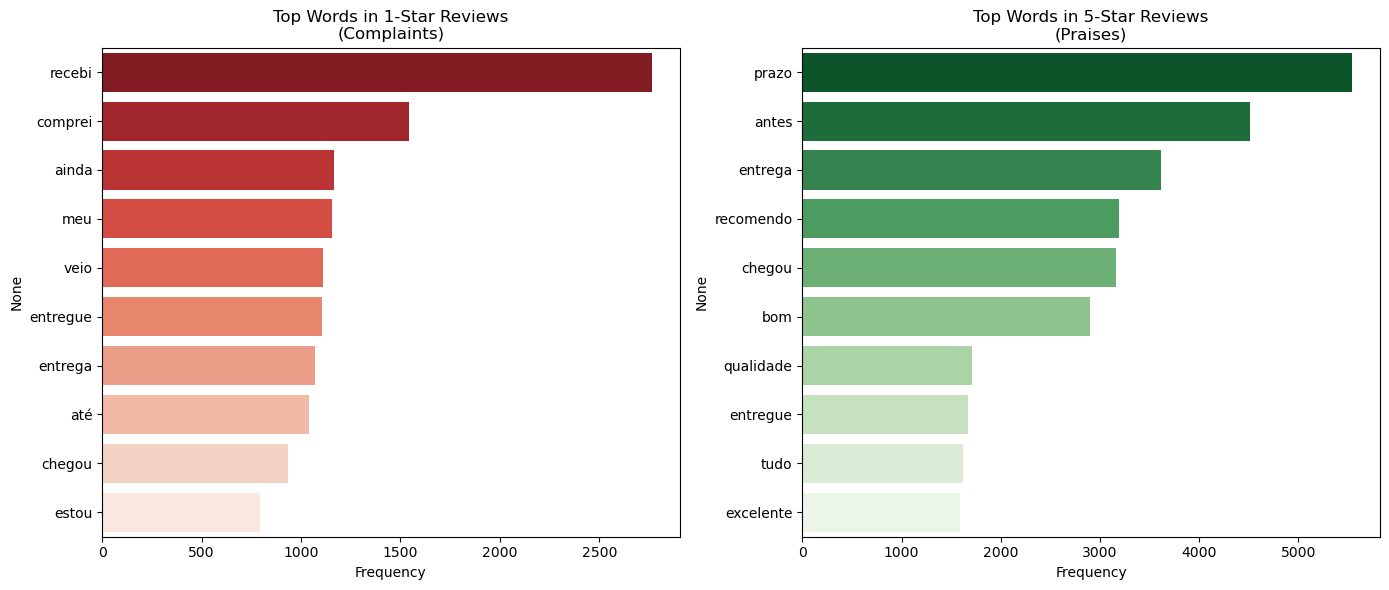

In [9]:
# Get top words for 1-star and 5-star reviews
top_1_star = get_top_keywords(text_only[text_only['review_score'] == 1]['review_comment_message'])
top_5_star = get_top_keywords(text_only[text_only['review_score'] == 5]['review_comment_message'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    x=top_1_star.values, 
    y=top_1_star.index, 
    ax=axes[0], 
    hue=top_1_star.index, 
    palette='Reds_r', 
    legend=False
)
axes[0].set_title('Top Words in 1-Star Reviews\n(Complaints)', fontsize=12)
axes[0].set_xlabel('Frequency')

sns.barplot(
    x=top_5_star.values, 
    y=top_5_star.index, 
    ax=axes[1], 
    hue=top_5_star.index, 
    palette='Greens_r', 
    legend=False
)
axes[1].set_title('Top Words in 5-Star Reviews\n(Praises)', fontsize=12)
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()